[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pablolob/calc_dif_equations_LAB/blob/main/08_Cartilago_Viscoelastico.ipynb)

# 🦴 LAB 8: Cartílago Viscoelástico — EDO Lineal de 2º Orden

¿Se podría modelar una rodilla como un muelle? Veamos como se comportaría si la simplificamos como un sistema masa-muelle-amortiguado.

Cuando aterrizas tras un salto, **¿por qué tus rodillas no rebotan como un muelle**? Porque el cartílago articular no es un muelle puro: tiene amortiguamiento viscoso. Cuando se diseña una **prótesis de rodilla**, la pregunta clave es: ¿qué amortiguamiento debe tener para imitar al cartílago sano?

El cartílago se modela como un sólido de **Kelvin–Voigt** con masa efectiva $m$, rigidez $k$ y amortiguamiento $b$. La EDO que rige su desplazamiento $x(t)$ tras un impacto es:

$$m\,\ddot{x} + b\,\dot{x} + k\,x = 0$$

Esta es una **EDO lineal de 2º orden** con coeficientes constantes. Resolverla revela tres regímenes biomecánicos con consecuencias clínicas directas.

---

In [6]:
# !!! ESTA CELDA ES SOLO DE CONFIGURACIÓN.
# Este bloque contiene código auxiliar; ejecútalo para poder visualizar los resultados más adelante.
import numpy as np
import matplotlib.pyplot as plt

def dibujar_respuesta(t, x_dict):
    """x_dict: { 'etiqueta': (x_array, color, info_clinica) }"""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axhline(0, color='black', lw=0.8)
    for etiqueta, (x, color, info) in x_dict.items():
        ax.plot(t, x, lw=2.3, color=color, label=f'{etiqueta}  —  {info}')
    ax.set_xlabel('Tiempo (s)'); ax.set_ylabel('Desplazamiento x(t) (mm)')
    ax.set_title('Respuesta del cartílago tras un impacto unitario')
    ax.legend(loc='upper right'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def dibujar_zeta_curve(zeta_actual=None):
    """Tiempo de asentamiento (caer por debajo del 5%) en función de zeta.
    Con omega_n = 1, el tiempo está en unidades de 1/omega_n."""
    zetas = np.linspace(0.1, 3.0, 300)
    omega_n = 1.0
    t_settle = []
    for z in zetas:
        # Ventana temporal adaptativa: para ζ pequeño la envolvente decae lentamente
        # y necesitamos ir más allá; antes estaba fijo en t=30 y truncaba la curva.
        t_max = max(40.0, 1.5 * np.log(40) / (z * omega_n))
        t = np.linspace(0, t_max, 6000)
        if z < 1:
            wd = omega_n * np.sqrt(1 - z**2)
            x = np.exp(-z*omega_n*t) * (np.cos(wd*t) + (z/np.sqrt(1-z**2)) * np.sin(wd*t))
        elif np.isclose(z, 1):
            x = (1 + omega_n*t) * np.exp(-omega_n*t)
        else:
            r1 = -omega_n*(z - np.sqrt(z**2 - 1))
            r2 = -omega_n*(z + np.sqrt(z**2 - 1))
            A = r2 / (r2 - r1); B = -r1 / (r2 - r1)
            x = A*np.exp(r1*t) + B*np.exp(r2*t)
        idx = np.where(np.abs(x) > 0.05)[0]
        t_settle.append(t[idx[-1]] if len(idx) else 0)
    t_settle = np.array(t_settle)
    z_opt = zetas[np.argmin(t_settle)]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(zetas, t_settle, 'b-', lw=2.5)
    ax.axvline(1.0, color='green', linestyle='--', lw=1.5, label=r'$\zeta = 1$  (crítico)')
    ax.axvline(z_opt, color='orange', linestyle='--', lw=1.5,
               label=fr'$\zeta_{{\mathrm{{óptimo}}}} \approx {z_opt:.2f}$  (mínimo)')
    if zeta_actual is not None:
        ax.axvline(zeta_actual, color='red', linestyle=':', lw=2,
                   label=f'$\\zeta$ caso clínico = {zeta_actual:.2f}')
    ax.set_xlabel(r'Coeficiente de amortiguamiento $\zeta$')
    ax.set_ylabel(r'Tiempo de asentamiento al 5%   (en unidades de $1/\omega_n$)')
    ax.set_title(r'Tiempo de recuperación según el régimen  ($\omega_n = 1$)')
    ax.set_ylim(0, min(60, np.max(t_settle)*1.05))
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 🔬 Resolución analítica

Probamos una solución exponencial $x(t) = e^{rt}$ y obtenemos la **ecuación característica**:

$$m r^2 + b r + k = 0$$

Definimos la **frecuencia natural** y el **factor de amortiguamiento**:

$$\omega_n = \sqrt{\dfrac{k}{m}}, \qquad \zeta = \dfrac{b}{2\sqrt{m\,k}}$$

El valor de $\zeta$ separa **tres regímenes** con interpretación clínica directa:

| Régimen | Condición | Interpretación clínica |
|---|---|---|
| **Subamortiguado** | $\zeta < 1$ | Cartílago joven: oscila tras el impacto. mayor componente elástica |
| **Críticamente amortiguado** | $\zeta = 1$ | **Prótesis ideal**: retorno al equilibrio lo más rápido posible sin rebote |
| **Sobreamortiguado** | $\zeta > 1$ | Cartílago artrítico/fibroso: rígido, retorno muy lento, dolor articular |

<details>
<summary><b>Las tres soluciones explícitas</b></summary>

Con condiciones iniciales $x(0)=1$, $\dot{x}(0)=0$:

- **Sub** ($\zeta < 1$): $\;x(t) = e^{-\zeta\omega_n t}\!\left[\cos(\omega_d t) + \dfrac{\zeta}{\sqrt{1-\zeta^2}}\sin(\omega_d t)\right]$ con $\omega_d = \omega_n\sqrt{1-\zeta^2}$
- **Crítico** ($\zeta = 1$): $\;x(t) = (1 + \omega_n t)\,e^{-\omega_n t}$
- **Sobre** ($\zeta > 1$): combinación de dos exponenciales reales decrecientes
</details>

---

### 🛠️ ¡TU TURNO! — Calcula los regímenes

Para los tres pacientes/dispositivos: calcula $\omega_n$ y $\zeta$ e identifica el régimen. Después calcula el **amortiguamiento ideal** $b^* = 2\sqrt{m\,k}$ que da régimen crítico en el caso "prótesis".

In [ ]:
# Tres casos clínicos:
casos = {
    'Cartílago joven (sano)':  {'m': 0.05, 'k': 4.0,  'b': 0.5},
    'Cartílago artrítico':     {'m': 0.05, 'k': 12.0, 'b': 2.5},
    'Prótesis (a diseñar)':    {'m': 0.05, 'k': 6.0,  'b': None},  # b lo decides tú
}

# Calculamos b* óptimo para la prótesis (amortiguamiento crítico):
m_p = casos['Prótesis (a diseñar)']['m']
k_p = casos['Prótesis (a diseñar)']['k']

b_critico = None    # <--- ¡Tu turno 1! Fórmula del amortiguamiento crítico
casos['Prótesis (a diseñar)']['b'] = b_critico

# Para cada caso calculamos omega_n y zeta:
for nombre, p in casos.items():
    omega_n = None    # <--- ¡Tu turno 2! Frecuencia natural
    zeta    = None    # <--- ¡Tu turno 3! Factor de amortiguamiento
    p['omega_n'] = omega_n
    p['zeta']    = zeta
    regimen = 'sub' if zeta < 1 else ('crítico' if np.isclose(zeta, 1) else 'sobre')
    print(f'{nombre:30s}  ω_n = {omega_n:.2f}  rad/s   ζ = {zeta:.2f}  →  {regimen}')

Cartílago joven (sano)          ω_n = 8.94  rad/s   ζ = 0.56  →  sub
Cartílago artrítico             ω_n = 15.49  rad/s   ζ = 1.61  →  sobre
Prótesis (a diseñar)            ω_n = 10.95  rad/s   ζ = 1.00  →  crítico


<details>
<summary><b>¿Atascado? Haz clic aquí para ver la Solución</b></summary>

```python
b_critico = 2 * np.sqrt(m_p * k_p)

omega_n = np.sqrt(p['k'] / p['m'])
zeta    = p['b'] / (2 * np.sqrt(p['m'] * p['k']))
```
</details>

### 📈 Visualización de los tres regímenes

Ejecuta la celda siguiente para comparar la respuesta de los tres casos al mismo impacto. Observa cómo la prótesis (régimen crítico) es la que vuelve antes al equilibrio sin rebotar.

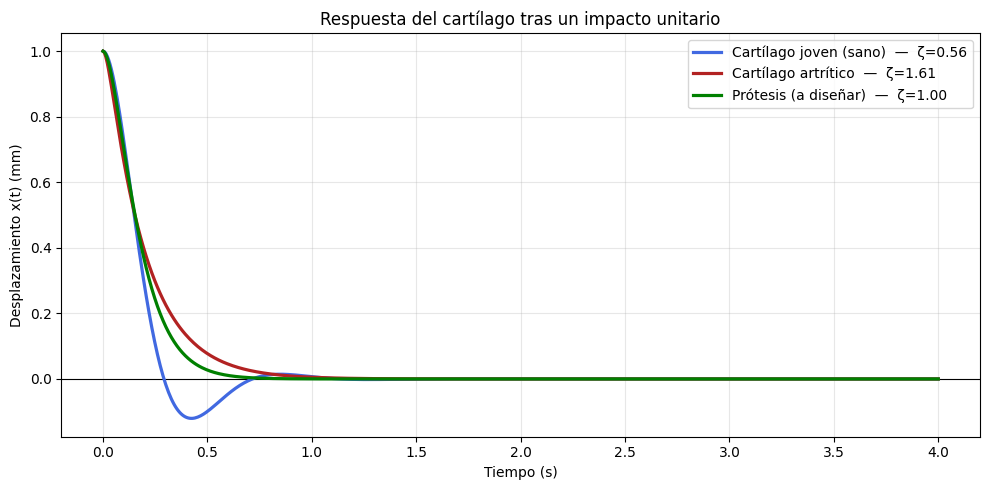

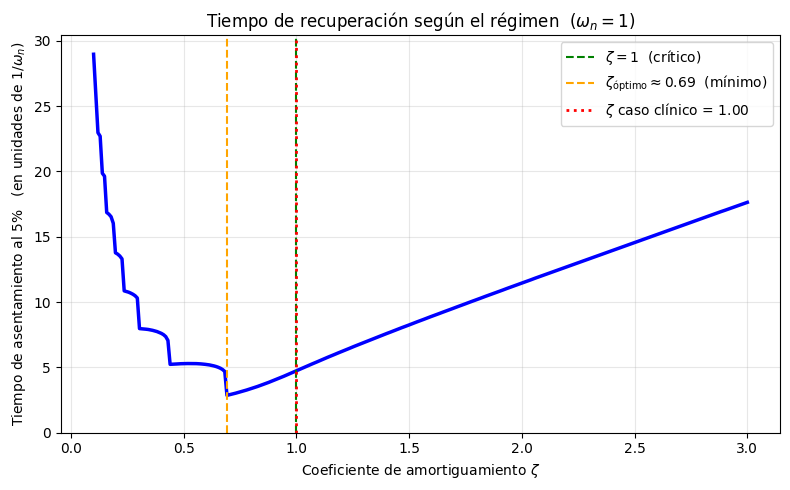

In [7]:
def x_de_t(t, omega_n, zeta):
    """Solución analítica para x(0)=1, x'(0)=0."""
    if zeta < 1:
        wd = omega_n * np.sqrt(1 - zeta**2)
        return np.exp(-zeta*omega_n*t) * (np.cos(wd*t) + (zeta/np.sqrt(1-zeta**2)) * np.sin(wd*t))
    elif np.isclose(zeta, 1):
        return (1 + omega_n*t) * np.exp(-omega_n*t)
    else:
        r1 = -omega_n*(zeta - np.sqrt(zeta**2 - 1))
        r2 = -omega_n*(zeta + np.sqrt(zeta**2 - 1))
        A = r2 / (r2 - r1); B = -r1 / (r2 - r1)
        return A*np.exp(r1*t) + B*np.exp(r2*t)

t = np.linspace(0, 4, 600)
colores = {'Cartílago joven (sano)': 'royalblue',
           'Cartílago artrítico':    'firebrick',
           'Prótesis (a diseñar)':   'green'}
etiquetas = {}
for nombre, p in casos.items():
    x = x_de_t(t, p['omega_n'], p['zeta'])
    info = f"ζ={p['zeta']:.2f}"
    etiquetas[nombre] = (x, colores[nombre], info)

dibujar_respuesta(t, etiquetas)
dibujar_zeta_curve(zeta_actual=casos['Prótesis (a diseñar)']['zeta'])

### 🔍 Experimenta y Reflexiona

- **Edad**: con la edad, $k$ tiende a aumentar (cartílago más rígido) y $b$ también. Prueba `k=8, b=1.0`. ¿Qué régimen sale?
- **Prótesis defectuosa**: si el fabricante pone `b = 0.5 * b_critico` en lugar de `b_critico`, ¿qué pasa al andar?
- **Lesión deportiva**: si el ligamento está dañado, $k$ baja a la mitad. ¿La articulación se vuelve más estable o más inestable?

---

## 📚 Referencias

**Mow, V.C. & Huiskes, R. (2005).** *Basic Orthopaedic Biomechanics & Mechano-biology* (3rd ed.). Lippincott Williams & Wilkins.

**Ateshian, G.A. & Mow, V.C. (2005).** *Friction, Lubrication, and Wear of Articular Cartilages.* En *Basic Orthopaedic Biomechanics*, 447–494.

**Fung, Y.C. (1993).** *Biomechanics: Mechanical Properties of Living Tissues* (2nd ed.). Springer-Verlag.  
[→ DOI: 10.1007/978-1-4757-2257-4](https://doi.org/10.1007/978-1-4757-2257-4)

---

## Mis Respuestas

**Pregunta 1.**

*Escribe aquí tu respuesta...*

---

**Pregunta 2.**

*Escribe aquí tu respuesta...*

---